In [79]:
import pandas as pd
import numpy as np
import os
import json
import re
import warnings
warnings.filterwarnings('ignore')

#NLP
import nltk
from nltk.corpus import stopwords

#Sklearn - Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

#Sklearn - Models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier

#Sklearn - Model Selection and Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

#Feature Selection
from sklearn.feature_selection import SelectKBest, chi2

#Preprocessing / Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Sparse matrix operations
from scipy.sparse import hstack

#Download NLTK data
nltk.download('stopwords', quiet=True)

True

In [80]:
#DATA LOADING FUNCTIONS

def load_clickbait17_data(base_path):
    """
    Load Clickbait17 dataset (2017 format)

    Args:
        base_path: Path containing instances.jsonl and truth.jsonl

    Returns:
        DataFrame with columns ['headline', 'label']
    """
    print(f"\n Loading 2017 data from: {base_path}")

    instances_path = os.path.join(base_path, "instances.jsonl")
    truth_path = os.path.join(base_path, "truth.jsonl")

    # Load JSONL files
    instances = pd.read_json(instances_path, lines=True)
    truth = pd.read_json(truth_path, lines=True)

    # Merge on ID
    df = instances.merge(truth, on="id")

    # Extract headline safely
    df['headline'] = df['postText'].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else str(x)
    )

    # Convert to binary label
    df['label'] = (df['truthMean'] >= 0.5).astype(int)

    # Keep relevant columns and clean
    df = df[['headline', 'label']].dropna().copy()

    # Print stats
    print(f"✓ Loaded {len(df)} samples")
    print(f"  - Clickbait: {df['label'].sum()} ({df['label'].mean()*100:.1f}%)")
    print(f"  - Non-clickbait: {(1 - df['label']).sum()} ({(1 - df['label'].mean())*100:.1f}%)")

    return df


def load_webis16_data(base_path):
    """
    Load Webis Clickbait-16 dataset (2016 format)

    Args:
        base_path: Path to webis-clickbait-16 folder

    Returns:
        DataFrame with columns ['headline', 'label']
    """
    print(f"\nLoading 2016 data from: {base_path}")

    problems_path = os.path.join(base_path, "problems")
    truth_file = os.path.join(base_path, "truth", "majority.csv")

    # Load truth labels 
    truth_df = pd.read_csv(truth_file, header=None, dtype={0: str})
    truth_df.columns = ["id", "label_str"] 
    truth_map = dict(zip(truth_df["id"], truth_df["label_str"]))

    data = []

    folders = sorted(os.listdir(problems_path))

    for folder in folders:
        folder_path = os.path.join(problems_path, folder)

        if not os.path.isdir(folder_path):
            continue

        #Get label safely using ID
        label_str = truth_map.get(folder)
        if label_str is None:
            continue

        label = 1 if label_str == "clickbait" else 0

        files = os.listdir(folder_path)

        for f in files:
            if f.endswith(".json"):
                json_path = os.path.join(folder_path, f)

                try:
                    with open(json_path, "r", encoding="utf-8") as file:
                        problem = json.load(file)
                except:
                    continue

                # Extract headline safely
                headline = None

                if "postText" in problem:
                    val = problem["postText"]
                    headline = val[0] if isinstance(val, list) and len(val) > 0 else val
                elif "text" in problem:
                    headline = problem["text"]
                elif "title" in problem:
                    headline = problem["title"]

                # Ensure valid string
                if headline and isinstance(headline, str):
                    data.append([headline, label])

                break  

    # Create DataFrame
    df = pd.DataFrame(data, columns=["headline", "label"]).dropna()

    # Print stats
    print(f"✓ Loaded {len(df)} samples")
    print(f"  - Clickbait: {df['label'].sum()} ({df['label'].mean()*100:.1f}%)")
    print(f"  - Non-clickbait: {(1 - df['label']).sum()} ({(1 - df['label'].mean())*100:.1f}%)")

    return df

In [81]:
#TEXT PREPROCESSING 
class TextPreprocessor:
    """
    Advanced text preprocessing for lexical modeling
    Handles both clean text (for TF-IDF) and raw text (for feature engineering)
    """
    
    def __init__(self, remove_stopwords=False, lowercase=True):
        self.remove_stopwords = remove_stopwords
        self.lowercase = lowercase
        
        #  CUSTOM STOPWORDS (keep important clickbait words)
        base_stopwords = set(stopwords.words('english'))
        
        important_words = {
            "you", "your", "yours", "what", "which", "who", "whom",
            "this", "that", "these", "those", "why", "how"
        }
        
        self.stop_words = base_stopwords - important_words if remove_stopwords else set()
    
    def clean_text(self, text):
        """
        Clean text for TF-IDF (word-based features)
        """
        if pd.isna(text):
            return ""
        
        # Convert to string
        text = str(text)
        
        # Lowercase
        if self.lowercase:
            text = text.lower()
        
        # Remove special characters BUT keep spaces
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        
        # Normalize whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        
        # Optional stopword removal
        if self.remove_stopwords:
            words = text.split()
            words = [w for w in words if w not in self.stop_words]
            text = " ".join(words)
        
        return text
    
    def clean_text_preserve_punctuation(self, text):
        """
        Clean text for feature engineering (KEEP punctuation)
        """
        if pd.isna(text):
            return ""
        
        text = str(text)
        
        if self.lowercase:
            text = text.lower()
        
        # Only normalize whitespace (Keep punctuation)
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text

In [82]:
class ClickbaitFeatureExtractor:
    
    def __init__(self):
        self.clickbait_phrases = [
            "won't believe", "will shock", "what happens",
            "this will", "you need to", "find out",
            "you won't believe what", "what happens next",
            "the truth about", "this is why"
        ]
        
        self.question_words = [
            "what", "why", "how", "when", "where", "who", "which"
        ]
    
    def extract_features(self, text):
        
        if pd.isna(text):
            text = ""
        
        text = str(text)
        text_lower = text.lower()
        words = text.split()
        
        features = []
        
        # Basic
        features.append(len(text))
        features.append(len(words))
        
        # Clickbait signals
        features.append(1 if ('you' in text_lower or 'your' in text_lower) else 0)
        features.append(1 if '?' in text else 0)
        features.append(1 if '!' in text else 0)
        features.append(text.count('?'))
        features.append(text.count('!'))
        
        # Phrase detection (improved)
        contains_phrase = any(re.search(rf"\b{phrase}\b", text_lower) for phrase in self.clickbait_phrases)
        features.append(1 if contains_phrase else 0)
        
        # Uppercase features
        features.append(sum(1 for word in words if word.isupper()))
        features.append(1 if any(word.isupper() for word in words) else 0)
        
        # Structure
        features.append(1 if text and text[0].isdigit() else 0)
        first_word = words[0].lower() if words else ""
        features.append(1 if first_word in self.question_words else 0)
        features.append(1 if any(char.isdigit() for char in text) else 0)
        
        # Ratios
        features.append(np.mean([len(w) for w in words]) if words else 0)
        features.append(text.count('!') / (len(text)+1))
        features.append(text.count('?') / (len(text)+1))
        features.append(sum(1 for c in text if c.isupper()) / (len(text)+1))
        
        # Advanced
        features.append(len(words) - len(set(words)))  # repetition
        features.append(sum(1 for w in words if len(w) > 7) / (len(words)+1))
        
        return features
    
    def extract_batch(self, texts):
        return np.array([self.extract_features(text) for text in texts])

In [83]:
# LOAD 2017 TEST DATA 

def load_clickbait17_test(base_path):
    """
    Load 2017 test dataset WITH labels

    Args:
        base_path: Path containing instances.jsonl and truth.jsonl

    Returns:
        DataFrame with columns ['headline', 'label']
    """
    print(f"\n Loading 2017 TEST data from: {base_path}")
    
    instances_path = os.path.join(base_path, "instances.jsonl")
    truth_path = os.path.join(base_path, "truth.jsonl")
    
    # Load both files
    instances = pd.read_json(instances_path, lines=True)
    truth = pd.read_json(truth_path, lines=True)
    
    # Merge on ID
    df = instances.merge(truth, on="id")
    
    # Extract headline safely
    df['headline'] = df['postText'].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else str(x)
    )
    
    # Convert to binary label
    df['label'] = (df['truthMean'] >= 0.5).astype(int)
    
    # Keep relevant columns
    df = df[['headline', 'label']].dropna().copy()
    
    # Print stats
    print(f" Loaded {len(df)} test samples")
    print(f"  - Clickbait: {df['label'].sum()} ({df['label'].mean()*100:.1f}%)")
    print(f"  - Non-clickbait: {(1 - df['label']).sum()} ({(1 - df['label'].mean())*100:.1f}%)")
    
    return df

In [85]:
# LOAD ALL DATASETS 

print("LOADING ALL DATASETS")

# Base path
BASE_PATH = "C:/Users/praneeth/OneDrive - iiit-b/1NLPDL/project/data"

# Paths 
PATH_2017_SMALL = os.path.join(
    BASE_PATH,
    "clickbait17-train-170331",
    "clickbait17-train-170331"
)

PATH_2017_LARGE = os.path.join(
    BASE_PATH,
    "clickbait17-train-170630",
    "clickbait17-validation-170630"
)

PATH_2017_TEST = os.path.join(
    BASE_PATH,
    "clickbait17-test-170720",
    "clickbait17-test-170720"
)

PATH_2016 = os.path.join(
    BASE_PATH,
    "corpus-webis-clickbait-16",
    "webis-clickbait-16"
)

print("1. Loading 2017 SMALL dataset")
df_2017_small = load_clickbait17_data(PATH_2017_SMALL)

print("\n2. Loading 2017 LARGE dataset")
df_2017_large = load_clickbait17_data(PATH_2017_LARGE)

print("\n3. Loading 2017 TEST dataset (WITH LABELS)")
df_2017_test = load_clickbait17_test(PATH_2017_TEST)

print("\n4. Loading 2016 dataset")
df_2016 = load_webis16_data(PATH_2016)


print("\nCombining 2017 SMALL + LARGE datasets")
df_2017_combined = pd.concat([df_2017_large, df_2017_small], ignore_index=True)

print(f"Combined Training Samples: {len(df_2017_combined)}")

print("\nCombined class distribution:")
print(f"  - Clickbait: {df_2017_combined['label'].sum()} ({df_2017_combined['label'].mean()*100:.1f}%)")
print(f"  - Non-clickbait: {(1 - df_2017_combined['label']).sum()} ({(1 - df_2017_combined['label'].mean())*100:.1f}%)")

print("\nDATASET SUMMARY")
print(f"2017 Combined Training: {len(df_2017_combined)} samples")
print(f"2017 Test:              {len(df_2017_test)} samples ")
print(f"2016 Test:              {len(df_2016)} samples")

LOADING ALL DATASETS
1. Loading 2017 SMALL dataset

 Loading 2017 data from: C:/Users/praneeth/OneDrive - iiit-b/1NLPDL/project/data\clickbait17-train-170331\clickbait17-train-170331
✓ Loaded 2459 samples
  - Clickbait: 710 (28.9%)
  - Non-clickbait: 1749 (71.1%)

2. Loading 2017 LARGE dataset

 Loading 2017 data from: C:/Users/praneeth/OneDrive - iiit-b/1NLPDL/project/data\clickbait17-train-170630\clickbait17-validation-170630
✓ Loaded 19538 samples
  - Clickbait: 4740 (24.3%)
  - Non-clickbait: 14798 (75.7%)

3. Loading 2017 TEST dataset (WITH LABELS)

 Loading 2017 TEST data from: C:/Users/praneeth/OneDrive - iiit-b/1NLPDL/project/data\clickbait17-test-170720\clickbait17-test-170720
 Loaded 18979 test samples
  - Clickbait: 4404 (23.2%)
  - Non-clickbait: 14575 (76.8%)

4. Loading 2016 dataset

Loading 2016 data from: C:/Users/praneeth/OneDrive - iiit-b/1NLPDL/project/data\corpus-webis-clickbait-16\webis-clickbait-16
✓ Loaded 2992 samples
  - Clickbait: 767 (25.6%)
  - Non-clickbait

In [86]:
# TEXT PREPROCESSING

print("TEXT PREPROCESSING")

# keep stopwords
preprocessor = TextPreprocessor(remove_stopwords=False, lowercase=True)
df_train_full = df_2017_combined.copy()

# Shuffle
df_train_full = df_train_full.sample(frac=1, random_state=42).reset_index(drop=True)

print("Preprocessing 2017 COMBINED training data")
df_train_full['clean_text'] = df_train_full['headline'].apply(preprocessor.clean_text)
df_train_full['text_with_punct'] = df_train_full['headline'].apply(
    preprocessor.clean_text_preserve_punctuation
)


print("Preprocessing 2017 TEST data")
df_2017_test['clean_text'] = df_2017_test['headline'].apply(preprocessor.clean_text)
df_2017_test['text_with_punct'] = df_2017_test['headline'].apply(
    preprocessor.clean_text_preserve_punctuation
)

print("Preprocessing 2016 data")
df_2016['clean_text'] = df_2016['headline'].apply(preprocessor.clean_text)
df_2016['text_with_punct'] = df_2016['headline'].apply(
    preprocessor.clean_text_preserve_punctuation
)

df_train_full = df_train_full[df_train_full['clean_text'].str.strip() != ""]


print("\nPREPROCESSING EXAMPLES:")

for i in range(min(3, len(df_train_full))):
    print(f"\nOriginal:  {df_train_full.iloc[i]['headline']}")
    print(f"Cleaned:   {df_train_full.iloc[i]['clean_text']}")
    print(f"Label:     {df_train_full.iloc[i]['label']} ({'Clickbait' if df_train_full.iloc[i]['label'] == 1 else 'Non-clickbait'})")

print("\n Preprocessing complete\n")

TEXT PREPROCESSING
Preprocessing 2017 COMBINED training data
Preprocessing 2017 TEST data
Preprocessing 2016 data

PREPROCESSING EXAMPLES:

Original:  Expert reveals the 5 best recipes to keep you slim and full of energy – and stop you getting 'hangry'
Cleaned:   expert reveals the best recipes to keep you slim and full of energy and stop you getting hangry
Label:     1 (Clickbait)

Original:  A gunman opened fire on the Champs-Élysées, killing a police officer and severely wounding another
Cleaned:   a gunman opened fire on the champs lys es killing a police officer and severely wounding another
Label:     0 (Non-clickbait)

Original:  What is your university doing to prevent rape? #sexualassault
Cleaned:   what is your university doing to prevent rape sexualassault
Label:     0 (Non-clickbait)

 Preprocessing complete



In [90]:
# TRAIN / VALIDATION SPLIT 

print("TRAIN/VALIDATION SPLIT")

X_clean = df_train_full['clean_text']            # Word-level features
X_punct = df_train_full['text_with_punct']       # For handcrafted features
y = df_train_full['label']

# SPLIT
X_clean_train, X_clean_val, X_punct_train, X_punct_val, y_train, y_val = train_test_split(
    X_clean,
    X_punct,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# LOGGING
print(f"Training set:   {len(X_clean_train)} samples")
print(f"Validation set: {len(X_clean_val)} samples")

print(f"\nTraining class distribution:")
print(f"  - Clickbait:     {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  - Non-clickbait: {(1-y_train).sum()} ({(1-y_train.mean())*100:.1f}%)")

print(f"\nValidation class distribution:")
print(f"  - Clickbait:     {y_val.sum()} ({y_val.mean()*100:.1f}%)")
print(f"  - Non-clickbait: {(1-y_val).sum()} ({(1-y_val.mean())*100:.1f}%)")

print("\nSanity Checks:")
print(f"  Train size + Val size = {len(X_clean_train) + len(X_clean_val)} ")
print(f"  No overlap between train & val: {set(X_clean_train.index).isdisjoint(set(X_clean_val.index))}")

print("\n✓ Split complete\n")

TRAIN/VALIDATION SPLIT
Training set:   17540 samples
Validation set: 4386 samples

Training class distribution:
  - Clickbait:     4313 (24.6%)
  - Non-clickbait: 13227 (75.4%)

Validation class distribution:
  - Clickbait:     1078 (24.6%)
  - Non-clickbait: 3308 (75.4%)

Sanity Checks:
  Train size + Val size = 21926 
  No overlap between train & val: True

✓ Split complete



BASELINE MODEL: TF-IDF + LOGISTIC REGRESSION
Baseline TF-IDF shape: (17540, 5000)
Vocabulary size: 5000

BASELINE RESULTS 

Training Accuracy:   0.8452
Validation Accuracy: 0.8096
Validation Precision:0.5877
Validation Recall:   0.7551
Validation F1:       0.6610
Validation AUC:      0.8529

Classification Report (Validation):
               precision    recall  f1-score   support

Non-clickbait       0.91      0.83      0.87      3308
    Clickbait       0.59      0.76      0.66      1078

     accuracy                           0.81      4386
    macro avg       0.75      0.79      0.76      4386
 weighted avg       0.83      0.81      0.82      4386


Confusion Matrix:
[[2737  571]
 [ 264  814]]
  TN: 2737  FP: 571
  FN: 264  TP: 814


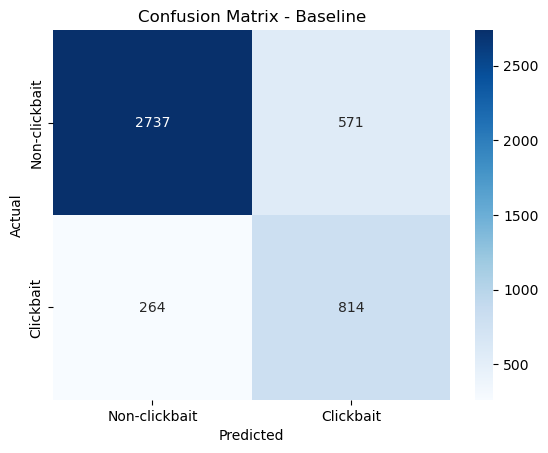


✓ Baseline model complete



In [91]:
# BASELINE MODEL - TF-IDF + LOGISTIC REGRESSION

print("BASELINE MODEL: TF-IDF + LOGISTIC REGRESSION")

# TF-IDF
vectorizer_baseline = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Fit only on training data
X_train_tfidf_baseline = vectorizer_baseline.fit_transform(X_clean_train)
X_val_tfidf_baseline = vectorizer_baseline.transform(X_clean_val)

print(f"Baseline TF-IDF shape: {X_train_tfidf_baseline.shape}")
print(f"Vocabulary size: {len(vectorizer_baseline.vocabulary_)}")

# MODEL
lr_baseline = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight='balanced',  
    random_state=42
)

lr_baseline.fit(X_train_tfidf_baseline, y_train)

# PREDICTIONS
y_pred_train_baseline = lr_baseline.predict(X_train_tfidf_baseline)
y_pred_val_baseline = lr_baseline.predict(X_val_tfidf_baseline)

# Probabilities (for AUC)
y_prob_val = lr_baseline.predict_proba(X_val_tfidf_baseline)[:, 1]

# METRICS
print("\nBASELINE RESULTS ")

train_acc = accuracy_score(y_train, y_pred_train_baseline)
val_acc = accuracy_score(y_val, y_pred_val_baseline)
prec = precision_score(y_val, y_pred_val_baseline)
rec = recall_score(y_val, y_pred_val_baseline)
f1 = f1_score(y_val, y_pred_val_baseline)
auc = roc_auc_score(y_val, y_prob_val)

print(f"\nTraining Accuracy:   {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Precision:{prec:.4f}")
print(f"Validation Recall:   {rec:.4f}")
print(f"Validation F1:       {f1:.4f}")
print(f"Validation AUC:      {auc:.4f}")

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_pred_val_baseline, 
                          target_names=['Non-clickbait', 'Clickbait']))

cm = confusion_matrix(y_val, y_pred_val_baseline)

print("\nConfusion Matrix:")
print(cm)
print(f"  TN: {cm[0,0]}  FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]}  TP: {cm[1,1]}")

# Optional: Heatmap (nice for report)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-clickbait', 'Clickbait'],
            yticklabels=['Non-clickbait', 'Clickbait'])
plt.title("Confusion Matrix - Baseline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------
# STORE RESULTS
# -------------------------
baseline_results = {
    'model': 'Baseline (TF-IDF 1-2 + LR)',
    'train_acc': train_acc,
    'val_acc': val_acc,
    'precision': prec,
    'recall': rec,
    'f1': f1,
    'auc': auc
}

print("\n✓ Baseline model complete\n")

In [93]:
# N-GRAM EXPERIMENTS 

print("N-GRAM EXPERIMENTS")

ngram_results = []

ngram_configs = [
    (1, 1),
    (1, 2),
    (1, 3),
    (2, 2),
    (2, 3),
]

for ngram_range in ngram_configs:
    print(f"Testing n-gram range: {ngram_range}")
    
    # VECTORIZER
    vectorizer_ngram = TfidfVectorizer(
        max_features=10000,
        ngram_range=ngram_range,
        min_df=2,
        max_df=0.95
    )
    
    X_train_ngram = vectorizer_ngram.fit_transform(X_clean_train)
    X_val_ngram = vectorizer_ngram.transform(X_clean_val)
    
    # MODEL
    lr_ngram = LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight='balanced',
        random_state=42
    )
    
    lr_ngram.fit(X_train_ngram, y_train)
    
    # PREDICTIONS
    y_pred_ngram = lr_ngram.predict(X_val_ngram)
    y_prob_ngram = lr_ngram.predict_proba(X_val_ngram)[:, 1]
    
    # METRICS
    acc = accuracy_score(y_val, y_pred_ngram)
    prec = precision_score(y_val, y_pred_ngram)
    rec = recall_score(y_val, y_pred_ngram)
    f1 = f1_score(y_val, y_pred_ngram)
    auc = roc_auc_score(y_val, y_prob_ngram)
    
    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred_ngram)
    
    # STORE RESULTS
    ngram_results.append({
        'ngram_range': str(ngram_range),
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auc': auc,
        'vocab_size': len(vectorizer_ngram.vocabulary_)
    })
    
    # PRINT RESULTS
    print(f"  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    print(f"  Vocabulary size: {len(vectorizer_ngram.vocabulary_)}")
    
    print("  Confusion Matrix:")
    print(f"    TN: {cm[0,0]}  FP: {cm[0,1]}")
    print(f"    FN: {cm[1,0]}  TP: {cm[1,1]}\n")

# RESULTS TABLE
print("\nN-GRAM COMPARISON TABLE")

df_ngram_results = pd.DataFrame(ngram_results)

# Sort by best F1
df_ngram_results = df_ngram_results.sort_values(by='f1', ascending=False)

print(df_ngram_results.to_string(index=False))

# BEST CONFIG
best_ngram = df_ngram_results.iloc[0]

print(f"\n✓ Best n-gram: {best_ngram['ngram_range']} with F1={best_ngram['f1']:.4f}\n")

N-GRAM EXPERIMENTS
Testing n-gram range: (1, 1)
  Accuracy: 0.8010 | Precision: 0.5760 | Recall: 0.7208 | F1: 0.6403 | AUC: 0.8490
  Vocabulary size: 10000
  Confusion Matrix:
    TN: 2736  FP: 572
    FN: 301  TP: 777

Testing n-gram range: (1, 2)
  Accuracy: 0.8128 | Precision: 0.5970 | Recall: 0.7338 | F1: 0.6583 | AUC: 0.8527
  Vocabulary size: 10000
  Confusion Matrix:
    TN: 2774  FP: 534
    FN: 287  TP: 791

Testing n-gram range: (1, 3)
  Accuracy: 0.8130 | Precision: 0.5966 | Recall: 0.7393 | F1: 0.6603 | AUC: 0.8523
  Vocabulary size: 10000
  Confusion Matrix:
    TN: 2769  FP: 539
    FN: 281  TP: 797

Testing n-gram range: (2, 2)
  Accuracy: 0.7595 | Precision: 0.5098 | Recall: 0.5575 | F1: 0.5326 | AUC: 0.7766
  Vocabulary size: 10000
  Confusion Matrix:
    TN: 2730  FP: 578
    FN: 477  TP: 601

Testing n-gram range: (2, 3)
  Accuracy: 0.7604 | Precision: 0.5115 | Recall: 0.5575 | F1: 0.5335 | AUC: 0.7742
  Vocabulary size: 10000
  Confusion Matrix:
    TN: 2734  FP: 57

In [96]:
# MULTIPLE CLASSIFIER COMPARISON
print("CLASSIFIER COMPARISON")

# BEST TF-IDF (from n-gram step)

vectorizer_best = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95
)

X_train_best = vectorizer_best.fit_transform(X_clean_train)
X_val_best = vectorizer_best.transform(X_clean_val)

# MODELS
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42),
    'Linear SVM': LinearSVC(max_iter=2000, C=1.0, class_weight='balanced', random_state=42),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'SGD Classifier': SGDClassifier(max_iter=1000, loss='log_loss', class_weight='balanced', random_state=42),
}

classifier_results = []

for name, clf in classifiers.items():
    print(f"Training {name}...")
    
    clf.fit(X_train_best, y_train)
    
    # PREDICTIONS
    y_pred = clf.predict(X_val_best)
    
    # AUC HANDLING 
    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_val_best)[:, 1]
        auc = roc_auc_score(y_val, y_prob)
    elif hasattr(clf, "decision_function"):
        y_score = clf.decision_function(X_val_best)
        auc = roc_auc_score(y_val, y_score)
    else:
        auc = None

    # METRICS
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    
    # STORE RESULTS
    classifier_results.append({
        'Classifier': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'AUC': auc
    })
    
    print(f"  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    
    print("  Confusion Matrix:")
    print(f"    TN: {cm[0,0]}  FP: {cm[0,1]}")
    print(f"    FN: {cm[1,0]}  TP: {cm[1,1]}\n")

print("\nCLASSIFIER COMPARISON TABLE")

df_classifier_results = pd.DataFrame(classifier_results)
df_classifier_results = df_classifier_results.sort_values(by='F1', ascending=False)

print(df_classifier_results.to_string(index=False))

# BEST MODEL
best_classifier_row = df_classifier_results.iloc[0]

print(f"\n✓ Best classifier: {best_classifier_row['Classifier']} with F1={best_classifier_row['F1']:.4f}\n")

CLASSIFIER COMPARISON
Training Logistic Regression...
  Accuracy: 0.8130 | Precision: 0.5966 | Recall: 0.7393 | F1: 0.6603 | AUC: 0.8523
  Confusion Matrix:
    TN: 2769  FP: 539
    FN: 281  TP: 797

Training Linear SVM...
  Accuracy: 0.7923 | Precision: 0.5644 | Recall: 0.6790 | F1: 0.6164 | AUC: 0.8272
  Confusion Matrix:
    TN: 2743  FP: 565
    FN: 346  TP: 732

Training Naive Bayes...
  Accuracy: 0.8206 | Precision: 0.6980 | Recall: 0.4759 | F1: 0.5659 | AUC: 0.8445
  Confusion Matrix:
    TN: 3086  FP: 222
    FN: 565  TP: 513

Training SGD Classifier...
  Accuracy: 0.8060 | Precision: 0.5823 | Recall: 0.7449 | F1: 0.6536 | AUC: 0.8509
  Confusion Matrix:
    TN: 2732  FP: 576
    FN: 275  TP: 803


CLASSIFIER COMPARISON TABLE
         Classifier  Accuracy  Precision   Recall       F1      AUC
Logistic Regression  0.813041   0.596557 0.739332 0.660315 0.852260
     SGD Classifier  0.805974   0.582306 0.744898 0.653643 0.850889
         Linear SVM  0.792294   0.564379 0.679035 0

In [98]:
# CLASS IMBALANCE HANDLING 
print("CLASS IMBALANCE HANDLING")

print("Testing class_weight='balanced'\n")

# LOGISTIC REGRESSION
# WITHOUT balancing
lr_unbalanced = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_unbalanced.fit(X_train_best, y_train)
y_pred_lr_unbalanced = lr_unbalanced.predict(X_val_best)
y_prob_lr_unbalanced = lr_unbalanced.predict_proba(X_val_best)[:,1]

# WITH balancing
lr_balanced = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight='balanced',
    random_state=42
)
lr_balanced.fit(X_train_best, y_train)
y_pred_lr_balanced = lr_balanced.predict(X_val_best)
y_prob_lr_balanced = lr_balanced.predict_proba(X_val_best)[:,1]

# SVM

# WITHOUT balancing
svm_unbalanced = LinearSVC(max_iter=2000, C=1.0, random_state=42)
svm_unbalanced.fit(X_train_best, y_train)
y_pred_svm_unbalanced = svm_unbalanced.predict(X_val_best)
y_score_svm_unbalanced = svm_unbalanced.decision_function(X_val_best)

# WITH balancing
svm_balanced = LinearSVC(
    max_iter=2000,
    C=1.0,
    class_weight='balanced',
    random_state=42
)
svm_balanced.fit(X_train_best, y_train)
y_pred_svm_balanced = svm_balanced.predict(X_val_best)
y_score_svm_balanced = svm_balanced.decision_function(X_val_best)

# RESULTS FUNCTION
def print_metrics(name, y_true, y_pred, y_score):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_score)

    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{name}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"AUC:       {auc:.4f}")
    print(f"Confusion Matrix → TN:{cm[0,0]} FP:{cm[0,1]} FN:{cm[1,0]} TP:{cm[1,1]}")

print_metrics("LR WITHOUT BALANCING", y_val, y_pred_lr_unbalanced, y_prob_lr_unbalanced)
print_metrics("LR WITH BALANCING", y_val, y_pred_lr_balanced, y_prob_lr_balanced)

print_metrics("SVM WITHOUT BALANCING", y_val, y_pred_svm_unbalanced, y_score_svm_unbalanced)
print_metrics("SVM WITH BALANCING", y_val, y_pred_svm_balanced, y_score_svm_balanced)

print("\n Class balancing comparison complete\n")

CLASS IMBALANCE HANDLING
Testing class_weight='balanced'


LR WITHOUT BALANCING
Accuracy:  0.8210
Precision: 0.7438
Recall:    0.4147
F1:        0.5325
AUC:       0.8517
Confusion Matrix → TN:3154 FP:154 FN:631 TP:447

LR WITH BALANCING
Accuracy:  0.8130
Precision: 0.5966
Recall:    0.7393
F1:        0.6603
AUC:       0.8523
Confusion Matrix → TN:2769 FP:539 FN:281 TP:797

SVM WITHOUT BALANCING
Accuracy:  0.8203
Precision: 0.6651
Recall:    0.5417
F1:        0.5971
AUC:       0.8261
Confusion Matrix → TN:3014 FP:294 FN:494 TP:584

SVM WITH BALANCING
Accuracy:  0.7923
Precision: 0.5644
Recall:    0.6790
F1:        0.6164
AUC:       0.8272
Confusion Matrix → TN:2743 FP:565 FN:346 TP:732

 Class balancing comparison complete



In [101]:
# ADVANCED TF-IDF CONFIGURATION 

print("ADVANCED TF-IDF OPTIMIZATION")

# ADVANCED TF-IDF
vectorizer_advanced = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,   # log scaling
    use_idf=True,
    smooth_idf=True,
    norm='l2'
)

X_train_advanced = vectorizer_advanced.fit_transform(X_clean_train)
X_val_advanced   = vectorizer_advanced.transform(X_clean_val)

print(f"Advanced TF-IDF shape: {X_train_advanced.shape}")
print(f"Features: {len(vectorizer_advanced.vocabulary_)}")

# MODEL
lr_advanced = LogisticRegression(
    max_iter=1000,
    C=2.0,  # slightly weaker regularization
    class_weight='balanced',
    random_state=42
)

lr_advanced.fit(X_train_advanced, y_train)

# PREDICTIONS
y_pred_advanced = lr_advanced.predict(X_val_advanced)
y_prob_advanced = lr_advanced.predict_proba(X_val_advanced)[:,1]

# METRICS
acc = accuracy_score(y_val, y_pred_advanced)
prec = precision_score(y_val, y_pred_advanced)
rec = recall_score(y_val, y_pred_advanced)
f1 = f1_score(y_val, y_pred_advanced)
auc = roc_auc_score(y_val, y_prob_advanced)

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_advanced)

print("\n ADVANCED TF-IDF RESULTS ")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

print("\nConfusion Matrix:")
print(f"  TN: {cm[0,0]}  FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]}  TP: {cm[1,1]}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_advanced, 
                          target_names=['Non-clickbait', 'Clickbait']))

# COMPARE WITH BASELINE
print("\n IMPROVEMENT OVER BASELINE ")
print(f"F1 Improvement: {f1 - baseline_results['f1']:.4f}")

print("\n Advanced TF-IDF configuration complete\n")

ADVANCED TF-IDF OPTIMIZATION
Advanced TF-IDF shape: (17540, 10000)
Features: 10000

 ADVANCED TF-IDF RESULTS 
Accuracy:  0.8124
Precision: 0.5964
Recall:    0.7319
F1:        0.6572
AUC:       0.8505

Confusion Matrix:
  TN: 2774  FP: 534
  FN: 289  TP: 789

Classification Report:
               precision    recall  f1-score   support

Non-clickbait       0.91      0.84      0.87      3308
    Clickbait       0.60      0.73      0.66      1078

     accuracy                           0.81      4386
    macro avg       0.75      0.79      0.76      4386
 weighted avg       0.83      0.81      0.82      4386


 IMPROVEMENT OVER BASELINE 
F1 Improvement: -0.0038

 Advanced TF-IDF configuration complete



In [102]:
print("CHARACTER N-GRAMS")

# Character TF-IDF
vectorizer_char = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    max_features=5000,
    min_df=2,
    max_df=0.9
)

X_train_char = vectorizer_char.fit_transform(X_clean_train)
X_val_char   = vectorizer_char.transform(X_clean_val)

print(f"Character n-gram shape: {X_train_char.shape}")

lr_char = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42)
lr_char.fit(X_train_char, y_train)

y_pred_char = lr_char.predict(X_val_char)
y_prob_char = lr_char.predict_proba(X_val_char)[:,1]

cm_char = confusion_matrix(y_val, y_pred_char)

print("\nCHARACTER N-GRAMS ALONE")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_char):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_char):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_char):.4f}")
print(f"F1:        {f1_score(y_val, y_pred_char):.4f}")
print(f"AUC:       {roc_auc_score(y_val, y_prob_char):.4f}")
print(f"Confusion Matrix → TN:{cm_char[0,0]} FP:{cm_char[0,1]} FN:{cm_char[1,0]} TP:{cm_char[1,1]}")

print("\nCOMBINING WORD + CHARACTER N-GRAMS")

X_train_combined = hstack([X_train_advanced, X_train_char])
X_val_combined   = hstack([X_val_advanced, X_val_char])

print(f"Combined feature shape: {X_train_combined.shape}")

lr_combined = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42)
lr_combined.fit(X_train_combined, y_train)

y_pred_combined = lr_combined.predict(X_val_combined)
y_prob_combined = lr_combined.predict_proba(X_val_combined)[:,1]

cm_combined = confusion_matrix(y_val, y_pred_combined)

print("\nWORD + CHAR N-GRAMS RESULTS")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_combined):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_combined):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_combined):.4f}")
print(f"F1:        {f1_score(y_val, y_pred_combined):.4f}")
print(f"AUC:       {roc_auc_score(y_val, y_prob_combined):.4f}")
print(f"Confusion Matrix → TN:{cm_combined[0,0]} FP:{cm_combined[0,1]} FN:{cm_combined[1,0]} TP:{cm_combined[1,1]}")

print("\nCharacter n-grams boost performance!\n")

CHARACTER N-GRAMS
Character n-gram shape: (17540, 5000)

CHARACTER N-GRAMS ALONE
Accuracy:  0.7959
Precision: 0.5655
Recall:    0.7328
F1:        0.6384
AUC:       0.8530
Confusion Matrix → TN:2701 FP:607 FN:288 TP:790

COMBINING WORD + CHARACTER N-GRAMS
Combined feature shape: (17540, 15000)

WORD + CHAR N-GRAMS RESULTS
Accuracy:  0.8178
Precision: 0.6058
Recall:    0.7412
F1:        0.6667
AUC:       0.8649
Confusion Matrix → TN:2788 FP:520 FN:279 TP:799

Character n-grams boost performance!



In [103]:
print("HAND-CRAFTED FEATURE ENGINEERING")

feature_extractor = ClickbaitFeatureExtractor()

X_train_original = df_train_full.loc[X_clean_train.index, 'text_with_punct']
X_val_original   = df_train_full.loc[X_clean_val.index, 'text_with_punct']

X_train_handcrafted = feature_extractor.extract_batch(X_train_original.values)
X_val_handcrafted   = feature_extractor.extract_batch(X_val_original.values)

print(f"Hand-crafted feature shape: {X_train_handcrafted.shape}")

scaler = StandardScaler(with_mean=False)

X_train_handcrafted = scaler.fit_transform(X_train_handcrafted)
X_val_handcrafted   = scaler.transform(X_val_handcrafted)

lr_handcrafted = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42)
lr_handcrafted.fit(X_train_handcrafted, y_train)

y_pred_handcrafted = lr_handcrafted.predict(X_val_handcrafted)
y_prob_handcrafted = lr_handcrafted.predict_proba(X_val_handcrafted)[:,1]

cm_hand = confusion_matrix(y_val, y_pred_handcrafted)

print("\nHAND-CRAFTED FEATURES ALONE")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_handcrafted):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_handcrafted):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_handcrafted):.4f}")
print(f"F1:        {f1_score(y_val, y_pred_handcrafted):.4f}")
print(f"AUC:       {roc_auc_score(y_val, y_prob_handcrafted):.4f}")
print(f"Confusion Matrix → TN:{cm_hand[0,0]} FP:{cm_hand[0,1]} FN:{cm_hand[1,0]} TP:{cm_hand[1,1]}")

print("\nCOMBINING ALL FEATURES")

X_train_full_features = hstack([
    X_train_advanced,
    X_train_char,
    X_train_handcrafted
])

X_val_full_features = hstack([
    X_val_advanced,
    X_val_char,
    X_val_handcrafted
])

print(f"Full feature shape: {X_train_full_features.shape}")

lr_full = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42)
lr_full.fit(X_train_full_features, y_train)

y_pred_full = lr_full.predict(X_val_full_features)
y_prob_full = lr_full.predict_proba(X_val_full_features)[:,1]

cm_full = confusion_matrix(y_val, y_pred_full)

print("\nALL FEATURES COMBINED RESULTS")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_full):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_full):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_full):.4f}")
print(f"F1:        {f1_score(y_val, y_pred_full):.4f}")
print(f"AUC:       {roc_auc_score(y_val, y_prob_full):.4f}")
print(f"Confusion Matrix → TN:{cm_full[0,0]} FP:{cm_full[0,1]} FN:{cm_full[1,0]} TP:{cm_full[1,1]}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_full, target_names=['Non-clickbait', 'Clickbait']))

print("\nFeature engineering complete!\n")

HAND-CRAFTED FEATURE ENGINEERING
Hand-crafted feature shape: (17540, 19)

HAND-CRAFTED FEATURES ALONE
Accuracy:  0.7549
Precision: 0.5010
Recall:    0.6679
F1:        0.5726
AUC:       0.7841
Confusion Matrix → TN:2591 FP:717 FN:358 TP:720

COMBINING ALL FEATURES
Full feature shape: (17540, 15019)

ALL FEATURES COMBINED RESULTS
Accuracy:  0.8208
Precision: 0.6101
Recall:    0.7505
F1:        0.6730
AUC:       0.8743
Confusion Matrix → TN:2791 FP:517 FN:269 TP:809

Classification Report:
               precision    recall  f1-score   support

Non-clickbait       0.91      0.84      0.88      3308
    Clickbait       0.61      0.75      0.67      1078

     accuracy                           0.82      4386
    macro avg       0.76      0.80      0.77      4386
 weighted avg       0.84      0.82      0.83      4386


Feature engineering complete!



In [104]:
print("FEATURE SELECTION (CHI-SQUARED)")

print("Selecting top features to reduce noise and improve generalization...\n")

selector = SelectKBest(chi2, k=8000)

X_train_selected = selector.fit_transform(X_train_full_features, y_train)
X_val_selected   = selector.transform(X_val_full_features)

print(f"Original features: {X_train_full_features.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")

lr_selected = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42)
lr_selected.fit(X_train_selected, y_train)

y_pred_selected = lr_selected.predict(X_val_selected)
y_prob_selected = lr_selected.predict_proba(X_val_selected)[:,1]

cm_sel = confusion_matrix(y_val, y_pred_selected)

print("\nAFTER FEATURE SELECTION")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_selected):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_selected):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_selected):.4f}")
print(f"F1:        {f1_score(y_val, y_pred_selected):.4f}")
print(f"AUC:       {roc_auc_score(y_val, y_prob_selected):.4f}")
print(f"Confusion Matrix → TN:{cm_sel[0,0]} FP:{cm_sel[0,1]} FN:{cm_sel[1,0]} TP:{cm_sel[1,1]}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_selected, target_names=['Non-clickbait', 'Clickbait']))

print("\nCHANGE VS FULL MODEL")
print(f"F1 Change: {f1_score(y_val, y_pred_selected) - f1_full:.4f}")

print("\nFeature selection complete\n")

FEATURE SELECTION (CHI-SQUARED)
Selecting top features to reduce noise and improve generalization...

Original features: 15019
Selected features: 8000

AFTER FEATURE SELECTION
Accuracy:  0.8178
Precision: 0.6030
Recall:    0.7579
F1:        0.6716
AUC:       0.8750
Confusion Matrix → TN:2770 FP:538 FN:261 TP:817

Classification Report:
               precision    recall  f1-score   support

Non-clickbait       0.91      0.84      0.87      3308
    Clickbait       0.60      0.76      0.67      1078

     accuracy                           0.82      4386
    macro avg       0.76      0.80      0.77      4386
 weighted avg       0.84      0.82      0.82      4386


CHANGE VS FULL MODEL
F1 Change: -0.0164

Feature selection complete



In [105]:
print("HYPERPARAMETER TUNING")

print("Testing different C values for Logistic Regression...\n")

C_values = [0.5, 1.0, 2.0, 5.0]
tuning_results = []

for C in C_values:
    print(f"Testing C={C}...")
    
    lr_tuned = LogisticRegression(
        max_iter=1000,
        C=C,
        class_weight='balanced',
        random_state=42
    )

    lr_tuned.fit(X_train_selected, y_train)
    
    y_pred_tuned = lr_tuned.predict(X_val_selected)
    y_prob_tuned = lr_tuned.predict_proba(X_val_selected)[:,1]
    
    acc = accuracy_score(y_val, y_pred_tuned)
    prec = precision_score(y_val, y_pred_tuned)
    rec = recall_score(y_val, y_pred_tuned)
    f1 = f1_score(y_val, y_pred_tuned)
    auc = roc_auc_score(y_val, y_prob_tuned)
    
    cm = confusion_matrix(y_val, y_pred_tuned)
    
    tuning_results.append({
        'C': C,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'AUC': auc
    })
    
    print(f"  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    print(f"  Confusion Matrix → TN:{cm[0,0]} FP:{cm[0,1]} FN:{cm[1,0]} TP:{cm[1,1]}\n")

print("HYPERPARAMETER TUNING RESULTS")

df_tuning = pd.DataFrame(tuning_results)
df_tuning = df_tuning.sort_values(by='F1', ascending=False)

print(df_tuning.to_string(index=False))

best_C_row = df_tuning.iloc[0]
best_C = best_C_row['C']

print(f"\n✓ Best C value: {best_C} with F1={best_C_row['F1']:.4f}")

print("\nClassification Report (Best Model):")
best_model = LogisticRegression(max_iter=1000, C=best_C, class_weight='balanced', random_state=42)
best_model.fit(X_train_selected, y_train)
best_preds = best_model.predict(X_val_selected)

print(classification_report(y_val, best_preds, target_names=['Non-clickbait', 'Clickbait']))

print("\nCHANGE VS FULL MODEL")
print(f"F1 Change: {best_C_row['F1'] - f1_full:.4f}")

HYPERPARAMETER TUNING
Testing different C values for Logistic Regression...

Testing C=0.5...
  Accuracy: 0.8215 | Precision: 0.6093 | Recall: 0.7625 | F1: 0.6774 | AUC: 0.8752
  Confusion Matrix → TN:2781 FP:527 FN:256 TP:822

Testing C=1.0...
  Accuracy: 0.8178 | Precision: 0.6030 | Recall: 0.7579 | F1: 0.6716 | AUC: 0.8750
  Confusion Matrix → TN:2770 FP:538 FN:261 TP:817

Testing C=2.0...
  Accuracy: 0.8160 | Precision: 0.6001 | Recall: 0.7532 | F1: 0.6680 | AUC: 0.8720
  Confusion Matrix → TN:2767 FP:541 FN:266 TP:812

Testing C=5.0...
  Accuracy: 0.8133 | Precision: 0.5983 | Recall: 0.7310 | F1: 0.6580 | AUC: 0.8636
  Confusion Matrix → TN:2779 FP:529 FN:290 TP:788

HYPERPARAMETER TUNING RESULTS
  C  Accuracy  Precision   Recall       F1      AUC
0.5  0.821477   0.609340 0.762523 0.677379 0.875228
1.0  0.817829   0.602952 0.757885 0.671599 0.875043
2.0  0.816005   0.600148 0.753247 0.668038 0.872022
5.0  0.813269   0.598330 0.730983 0.658038 0.863593

✓ Best C value: 0.5 with F1=

In [106]:
print("THRESHOLD OPTIMIZATION")

print("Optimizing decision threshold for best F1 score...\n")

lr_final = LogisticRegression(
    max_iter=1000,
    C=best_C,
    class_weight='balanced',
    random_state=42
)

lr_final.fit(X_train_full_features, y_train)

y_prob_val = lr_final.predict_proba(X_val_full_features)[:, 1]

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
threshold_results = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_val >= thresh).astype(int)
    
    acc = accuracy_score(y_val, y_pred_thresh)
    prec = precision_score(y_val, y_pred_thresh)
    rec = recall_score(y_val, y_pred_thresh)
    f1 = f1_score(y_val, y_pred_thresh)
    auc = roc_auc_score(y_val, y_prob_val)  # same probs
    
    threshold_results.append({
        'Threshold': thresh,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'AUC': auc
    })
    
    print(f"Threshold: {thresh:.2f} → Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

df_threshold = pd.DataFrame(threshold_results)
df_threshold = df_threshold.sort_values(by='F1', ascending=False)

best_thresh_row = df_threshold.iloc[0]
best_threshold = best_thresh_row['Threshold']

print(f"\n✓ Best threshold: {best_threshold} with F1={best_thresh_row['F1']:.4f}")

# Best predictions
y_pred_best = (y_prob_val >= best_threshold).astype(int)
cm_best = confusion_matrix(y_val, y_pred_best)

print("\nConfusion Matrix (Best Threshold):")
print(f"  TN: {cm_best[0,0]}  FP: {cm_best[0,1]}")
print(f"  FN: {cm_best[1,0]}  TP: {cm_best[1,1]}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_best, target_names=['Non-clickbait', 'Clickbait']))

# Compare with default
default_f1 = f1_score(y_val, (y_prob_val >= 0.5).astype(int))

print("\nIMPROVEMENT OVER DEFAULT (0.5)")
print(f"F1 Gain: {best_thresh_row['F1'] - default_f1:.4f}")

THRESHOLD OPTIMIZATION
Optimizing decision threshold for best F1 score...

Threshold: 0.30 → Acc: 0.7159 | Prec: 0.4595 | Rec: 0.8850 | F1: 0.6049
Threshold: 0.35 → Acc: 0.7499 | Prec: 0.4949 | Rec: 0.8544 | F1: 0.6267
Threshold: 0.40 → Acc: 0.7745 | Prec: 0.5263 | Rec: 0.8256 | F1: 0.6428
Threshold: 0.45 → Acc: 0.8007 | Prec: 0.5683 | Rec: 0.7876 | F1: 0.6602
Threshold: 0.50 → Acc: 0.8215 | Prec: 0.6115 | Rec: 0.7505 | F1: 0.6739
Threshold: 0.55 → Acc: 0.8336 | Prec: 0.6448 | Rec: 0.7189 | F1: 0.6798
Threshold: 0.60 → Acc: 0.8447 | Prec: 0.6836 | Rec: 0.6855 | F1: 0.6846

✓ Best threshold: 0.6 with F1=0.6846

Confusion Matrix (Best Threshold):
  TN: 2966  FP: 342
  FN: 339  TP: 739

Classification Report:
               precision    recall  f1-score   support

Non-clickbait       0.90      0.90      0.90      3308
    Clickbait       0.68      0.69      0.68      1078

     accuracy                           0.84      4386
    macro avg       0.79      0.79      0.79      4386
 weight

In [107]:
print("FINAL MODEL - TRAINING ON FULL DATASET")

print("Training final model on complete 2017 combined training data\n")

X_full = df_train_full['clean_text']
X_full_original = df_train_full['text_with_punct']
y_full = df_train_full['label']

print("Extracting features from full training set")

# WORD TF-IDF
vectorizer_final_word = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)
X_full_word = vectorizer_final_word.fit_transform(X_full)

# CHARACTER TF-IDF
vectorizer_final_char = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    max_features=5000,
    min_df=2,
    max_df=0.9
)
X_full_char = vectorizer_final_char.fit_transform(X_full)

# HAND-CRAFTED FEATURES
X_full_handcrafted = feature_extractor.extract_batch(X_full_original.values)

scaler_final = StandardScaler(with_mean=False)
X_full_handcrafted = scaler_final.fit_transform(X_full_handcrafted)

# COMBINE FEATURES
X_full_combined = hstack([X_full_word, X_full_char, X_full_handcrafted])

print(f"Full training features shape: {X_full_combined.shape}")

# FEATURE SELECTION (IMPORTANT)
selector_final = SelectKBest(chi2, k=8000)
X_full_selected = selector_final.fit_transform(X_full_combined, y_full)

print(f"After feature selection: {X_full_selected.shape}")

# FINAL MODEL
print(f"\nTraining final model (C={best_C})")

model_final = LogisticRegression(
    max_iter=1000,
    C=best_C,
    class_weight='balanced',
    random_state=42
)

model_final.fit(X_full_selected, y_full)

# FINAL THRESHOLD
final_threshold = best_threshold

print("Final model trained!\n")

FINAL MODEL - TRAINING ON FULL DATASET
Training final model on complete 2017 combined training data

Extracting features from full training set
Full training features shape: (21926, 15019)
After feature selection: (21926, 8000)

Training final model (C=0.5)
Final model trained!



In [110]:
print("PREDICTIONS ON 2017 TEST SET")

X_test_2017 = df_2017_test['clean_text']
X_test_2017_original = df_2017_test['text_with_punct']

print("Transforming 2017 test data")

# WORD
X_test_2017_word = vectorizer_final_word.transform(X_test_2017)

# CHAR
X_test_2017_char = vectorizer_final_char.transform(X_test_2017)

# HANDCRAFTED
X_test_2017_handcrafted = feature_extractor.extract_batch(X_test_2017_original.values)
X_test_2017_handcrafted = scaler_final.transform(X_test_2017_handcrafted)

# COMBINE
X_test_2017_combined = hstack([
    X_test_2017_word,
    X_test_2017_char,
    X_test_2017_handcrafted
])

# FEATURE SELECTION (CRITICAL)
X_test_2017_selected = selector_final.transform(X_test_2017_combined)

# PREDICTIONS
y_prob_2017 = model_final.predict_proba(X_test_2017_selected)[:, 1]
y_pred_2017 = (y_prob_2017 >= final_threshold).astype(int)

# SUMMARY
num_clickbait = y_pred_2017.sum()
num_total = len(y_pred_2017)

print("\nTEST SET PREDICTIONS")
print(f"Total samples: {num_total}")
print(f"Predicted Clickbait: {num_clickbait} ({num_clickbait/num_total*100:.2f}%)")
print(f"Predicted Non-clickbait: {num_total - num_clickbait}")

# SAMPLE OUTPUT
print("\nSAMPLE PREDICTIONS")

for i in range(5):
    print(f"\nHeadline: {df_2017_test.iloc[i]['headline']}")
    print(f"Prediction: {'Clickbait' if y_pred_2017[i]==1 else 'Non-clickbait'}")
    print(f"Confidence: {y_prob_2017[i]:.4f}")

print("\nPredictions complete\n")

PREDICTIONS ON 2017 TEST SET
Transforming 2017 test data

TEST SET PREDICTIONS
Total samples: 18979
Predicted Clickbait: 4936 (26.01%)
Predicted Non-clickbait: 14043

SAMPLE PREDICTIONS

Headline: Johnny Manziel on Browns' No. 1 pick Myles Garrett: "He'll do wonders for the team"

🎥:
Prediction: Non-clickbait
Confidence: 0.1266

Headline: Fabio: California Is a 'Mess' Because of Liberal Policies
Prediction: Non-clickbait
Confidence: 0.1668

Headline: "He's been huge for us this year, man."
Prediction: Clickbait
Confidence: 0.8164

Headline: New Bears quarterback Mitchell Trubisky was greeted with some boos at his first public appearance.
Prediction: Non-clickbait
Confidence: 0.1063

Headline: It's not enough to let employees work flexible schedules if they're still afraid to ask
Prediction: Non-clickbait
Confidence: 0.5790

Predictions complete



In [112]:
print("EVALUATION ON 2017 TEST SET")

# Get labels
y_test_2017 = df_2017_test['label']

# Predictions already computed
# y_pred_2017
# y_prob_2017

print("\n2017 TEST RESULTS")
print(f"Accuracy:  {accuracy_score(y_test_2017, y_pred_2017):.4f}")
print(f"Precision: {precision_score(y_test_2017, y_pred_2017):.4f}")
print(f"Recall:    {recall_score(y_test_2017, y_pred_2017):.4f}")
print(f"F1 Score:  {f1_score(y_test_2017, y_pred_2017):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_2017, y_prob_2017):.4f}")

# Confusion Matrix
cm_2017 = confusion_matrix(y_test_2017, y_pred_2017)

print("\nConfusion Matrix:")
print(f"  TN: {cm_2017[0,0]}  FP: {cm_2017[0,1]}")
print(f"  FN: {cm_2017[1,0]}  TP: {cm_2017[1,1]}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_2017, y_pred_2017,
                          target_names=['Non-clickbait', 'Clickbait']))

print("\n✓ 2017 test evaluation complete\n")

EVALUATION ON 2017 TEST SET

2017 TEST RESULTS
Accuracy:  0.8518
Precision: 0.6613
Recall:    0.7411
F1 Score:  0.6989
AUC-ROC:   0.8954

Confusion Matrix:
  TN: 12903  FP: 1672
  FN: 1140  TP: 3264

Classification Report:
               precision    recall  f1-score   support

Non-clickbait       0.92      0.89      0.90     14575
    Clickbait       0.66      0.74      0.70      4404

     accuracy                           0.85     18979
    macro avg       0.79      0.81      0.80     18979
 weighted avg       0.86      0.85      0.85     18979


✓ 2017 test evaluation complete



In [114]:
print("CROSS-DATASET EVALUATION (2016)")

print("Testing model generalization on 2016 dataset...\n")

X_test_2016 = df_2016['clean_text']
X_test_2016_original = df_2016['text_with_punct']
y_test_2016 = df_2016['label']

print("Transforming 2016 test data")

# WORD
X_test_2016_word = vectorizer_final_word.transform(X_test_2016)

# CHAR
X_test_2016_char = vectorizer_final_char.transform(X_test_2016)

# HANDCRAFTED
X_test_2016_handcrafted = feature_extractor.extract_batch(X_test_2016_original.values)
X_test_2016_handcrafted = scaler_final.transform(X_test_2016_handcrafted)

# COMBINE
X_test_2016_combined = hstack([
    X_test_2016_word,
    X_test_2016_char,
    X_test_2016_handcrafted
])

# FEATURE SELECTION (CRITICAL)
X_test_2016_selected = selector_final.transform(X_test_2016_combined)

# PREDICT
y_prob_2016 = model_final.predict_proba(X_test_2016_selected)[:, 1]
y_pred_2016 = (y_prob_2016 >= final_threshold).astype(int)

# METRICS
print("\n2016 TEST SET RESULTS (CROSS-DATASET)")
print(f"Accuracy:  {accuracy_score(y_test_2016, y_pred_2016):.4f}")
print(f"Precision: {precision_score(y_test_2016, y_pred_2016):.4f}")
print(f"Recall:    {recall_score(y_test_2016, y_pred_2016):.4f}")
print(f"F1 Score:  {f1_score(y_test_2016, y_pred_2016):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_2016, y_prob_2016):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test_2016, y_pred_2016,
    target_names=['Non-clickbait', 'Clickbait']
))

cm_2016 = confusion_matrix(y_test_2016, y_pred_2016)

print("\nConfusion Matrix:")
print(f"  TN: {cm_2016[0,0]}  FP: {cm_2016[0,1]}")
print(f"  FN: {cm_2016[1,0]}  TP: {cm_2016[1,1]}")

print("\nCross-dataset evaluation complete\n")

CROSS-DATASET EVALUATION (2016)
Testing model generalization on 2016 dataset...

Transforming 2016 test data

2016 TEST SET RESULTS (CROSS-DATASET)
Accuracy:  0.8018
Precision: 0.7529
Recall:    0.3377
F1 Score:  0.4662
AUC-ROC:   0.8375

Classification Report:
               precision    recall  f1-score   support

Non-clickbait       0.81      0.96      0.88      2225
    Clickbait       0.75      0.34      0.47       767

     accuracy                           0.80      2992
    macro avg       0.78      0.65      0.67      2992
 weighted avg       0.79      0.80      0.77      2992


Confusion Matrix:
  TN: 2140  FP: 85
  FN: 508  TP: 259

Cross-dataset evaluation complete



In [115]:
print("FEATURE INTERPRETABILITY")

print("Extracting most important features\n")

coefficients = model_final.coef_[0]

# Word features
word_features = vectorizer_final_word.get_feature_names_out()

# Character features
char_features = vectorizer_final_char.get_feature_names_out()

# Handcrafted features
num_handcrafted = X_full_handcrafted.shape[1]
handcrafted_features = [f'handcrafted_{i}' for i in range(num_handcrafted)]

# ALL FEATURES BEFORE SELECTION
all_features = list(word_features) + list(char_features) + handcrafted_features

# SELECTED INDICES (IMPORTANT)
selected_indices = selector_final.get_support(indices=True)

# MAP SELECTED FEATURES
selected_features = [all_features[i] for i in selected_indices]

print(f"Total selected features: {len(selected_features)}")
print(f"Total coefficients: {len(coefficients)}")

# Create dataframe
df_importance = pd.DataFrame({
    'feature': selected_features,
    'coefficient': coefficients
})

df_importance['abs_coef'] = df_importance['coefficient'].abs()
df_importance = df_importance.sort_values('abs_coef', ascending=False)

# TOP CLICKBAIT FEATURES
print("\nTOP 20 CLICKBAIT INDICATORS")

top_clickbait = df_importance[df_importance['coefficient'] > 0].head(20)

for _, row in top_clickbait.iterrows():
    print(f"{row['feature']:40s} → {row['coefficient']:+.4f}")

# TOP NON-CLICKBAIT FEATURES
print("\nTOP 20 NON-CLICKBAIT INDICATORS")

top_non_clickbait = df_importance[df_importance['coefficient'] < 0].head(20)

for _, row in top_non_clickbait.iterrows():
    print(f"{row['feature']:40s} → {row['coefficient']:+.4f}")

print("\nFeature interpretation complete\n")

FEATURE INTERPRETABILITY
Extracting most important features

Total selected features: 8000
Total coefficients: 8000

TOP 20 CLICKBAIT INDICATORS
this                                     → +3.5618
these                                    → +2.5904
why                                      → +2.0991
this                                     → +1.9521
things                                   → +1.8495
this                                     → +1.7937
thi                                      → +1.7406
theory                                   → +1.6071
here                                     → +1.5855
the                                      → +1.5517
http                                     → +1.4594
his                                      → +1.4566
thes                                     → +1.4283
his                                      → +1.4230
the                                      → +1.4165
ous                                      → +1.3478
and it                                 

In [116]:
print("ERROR ANALYSIS")

errors_2016 = df_2016.copy()
errors_2016['prediction'] = y_pred_2016
errors_2016['probability'] = y_prob_2016
errors_2016['error'] = errors_2016['label'] != errors_2016['prediction']

TN, FP, FN, TP = cm_2016.ravel()

print(f"\nConfusion Matrix → TN:{TN} FP:{FP} FN:{FN} TP:{TP}")

# False Positives
fp_2016 = errors_2016[(errors_2016['label'] == 0) & (errors_2016['prediction'] == 1)]

print(f"\nFalse Positives: {len(fp_2016)}")

print("\nExample False Positives (Top 5 by confidence):")

for _, row in fp_2016.nlargest(5, 'probability').iterrows():
    print(f"Headline: {row['headline']}")
    print(f"Predicted: Clickbait (prob={row['probability']:.3f}), Actual: Non-clickbait\n")

# False Negatives
fn_2016 = errors_2016[(errors_2016['label'] == 1) & (errors_2016['prediction'] == 0)]

print(f"\nFalse Negatives: {len(fn_2016)}")

print("\nExample False Negatives (Top 5 hardest cases):")

for _, row in fn_2016.nsmallest(5, 'probability').iterrows():
    print(f"Headline: {row['headline']}")
    print(f"Predicted: Non-clickbait (prob={row['probability']:.3f}), Actual: Clickbait\n")

# Error patterns
print("\nERROR PATTERNS")

total_errors = len(errors_2016[errors_2016['error']])

print(f"Total errors: {total_errors} / {len(errors_2016)} ({total_errors/len(errors_2016)*100:.2f}%)")

fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

print(f"False Positive Rate (FPR): {fpr:.3f}")
print(f"False Negative Rate (FNR): {fnr:.3f}")

print("\nError analysis complete\n")

ERROR ANALYSIS

Confusion Matrix → TN:2140 FP:85 FN:508 TP:259

False Positives: 85

Example False Positives (Top 5 by confidence):
Headline: How to teach your kids about sugar http://t.co/xvjMLtzpA6
Predicted: Clickbait (prob=0.967), Actual: Non-clickbait

Headline: Why does the cable-TV bundle exist anyway? http://t.co/lJeTncNING
Predicted: Clickbait (prob=0.956), Actual: Non-clickbait

Headline: 21 of the most powerful photos of this week http://t.co/lPncaVYtLm http://t.co/JmvNbT2EOD
Predicted: Clickbait (prob=0.956), Actual: Non-clickbait

Headline: What do you think Apple will announce at #WWDC15? Here’s what we’re expecting http://t.co/E1nQwaWnti
Predicted: Clickbait (prob=0.949), Actual: Non-clickbait

Headline: Did you see 'Jurassic World' this weekend? Here's what the critics are saying. http://t.co/plIixg4ZGv http://t.co/OfNHYpGmXT
Predicted: Clickbait (prob=0.932), Actual: Non-clickbait


False Negatives: 508

Example False Negatives (Top 5 hardest cases):
Headline: Police b

In [117]:
# VALIDATION RE-EVALUATION

X_text = df_train_full['clean_text']
y_text = df_train_full['label']

X_train_tmp, X_val_tmp, y_train_tmp, y_val_tmp = train_test_split(
    X_text, y_text,
    test_size=0.2,
    random_state=42,
    stratify=y_text
)

# Get original text
X_val_original = df_train_full.loc[X_val_tmp.index, 'text_with_punct']

# WORD
X_val_word = vectorizer_final_word.transform(X_val_tmp)

# CHAR
X_val_char = vectorizer_final_char.transform(X_val_tmp)

# HANDCRAFTED
X_val_handcrafted = feature_extractor.extract_batch(X_val_original.values)
X_val_handcrafted = scaler_final.transform(X_val_handcrafted)

# COMBINE
X_val_combined = hstack([
    X_val_word,
    X_val_char,
    X_val_handcrafted
])

# FEATURE SELECTION (CRITICAL)
X_val_selected = selector_final.transform(X_val_combined)

# PREDICT
y_prob_val_final = model_final.predict_proba(X_val_selected)[:, 1]

# THRESHOLD SEARCH
thresholds = np.arange(0.3, 0.7, 0.05)

best_f1 = 0
best_val_threshold = 0.5

for t in thresholds:
    preds = (y_prob_val_final >= t).astype(int)
    f1 = f1_score(y_val_tmp, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_val_threshold = t

# FINAL PREDICTIONS
y_pred_val_final = (y_prob_val_final >= best_val_threshold).astype(int)

print(f"Best validation threshold: {best_val_threshold:.2f}")
print(f"Validation F1 at best threshold: {best_f1:.4f}\n")

# SUMMARY TABLE

summary = {
    'Dataset': ['2017 Validation (In-Distribution)', '2016 Test (Cross-Dataset)'],
    'Accuracy': [
        accuracy_score(y_val_tmp, y_pred_val_final),
        accuracy_score(y_test_2016, y_pred_2016)
    ],
    'Precision': [
        precision_score(y_val_tmp, y_pred_val_final),
        precision_score(y_test_2016, y_pred_2016)
    ],
    'Recall': [
        recall_score(y_val_tmp, y_pred_val_final),
        recall_score(y_test_2016, y_pred_2016)
    ],
    'F1-Score': [
        f1_score(y_val_tmp, y_pred_val_final),
        f1_score(y_test_2016, y_pred_2016)
    ]
}

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

# MODEL CONFIG

print("\nMODEL CONFIGURATION")

print(f"Classifier:         Logistic Regression")
print(f"C parameter:        {best_C}")
print(f"Class weighting:    Balanced")
print(f"Decision threshold: {best_threshold} (final) / {best_val_threshold:.2f} (validation)")

total_features = (
    len(vectorizer_final_word.vocabulary_) +
    len(vectorizer_final_char.vocabulary_) +
    X_full_handcrafted.shape[1]
)

print(f"\nFeatures:")
print(f"  - Word TF-IDF (1-3 grams):   {len(vectorizer_final_word.vocabulary_)}")
print(f"  - Character n-grams (3-5):   {len(vectorizer_final_char.vocabulary_)}")
print(f"  - Hand-crafted features:     {X_full_handcrafted.shape[1]}")
print(f"  - Total features (before selection): {total_features}")
print(f"  - After feature selection:   8000")

Best validation threshold: 0.55
Validation F1 at best threshold: 0.7463

                          Dataset  Accuracy  Precision   Recall  F1-Score
2017 Validation (In-Distribution)  0.866849   0.701797 0.796846  0.746308
        2016 Test (Cross-Dataset)  0.801805   0.752907 0.337679  0.466247

MODEL CONFIGURATION
Classifier:         Logistic Regression
C parameter:        0.5
Class weighting:    Balanced
Decision threshold: 0.6 (final) / 0.55 (validation)

Features:
  - Word TF-IDF (1-3 grams):   10000
  - Character n-grams (3-5):   5000
  - Hand-crafted features:     19
  - Total features (before selection): 15019
  - After feature selection:   8000


In [121]:
print("FINAL SUMMARY: LEXICAL CLICKBAIT DETECTION")

# DATASET SUMMARY
print("\nDATASETS USED")
print("Training Data:        2017 Train (170331 + 170630 combined)")
print(f"Total Training Size:  {len(df_train_full)} samples")

print("\nValidation:           20% split from training")
print(f"Validation Size:      {len(y_val_tmp)} samples")

print("\nTest (In-Domain):     2017 Test (170720)")
print(f"Test Size:            {len(df_2017_test)} samples")

print("\nCross-Dataset:        2016 Webis Clickbait")
print(f"Cross Test Size:      {len(df_2016)} samples")

# MODEL CONFIGURATION
print("BEST MODEL CONFIGURATION")

print("Classifier:           Logistic Regression")
print(f"C parameter:          {best_C}")
print("Class weighting:      Balanced")
print(f"Decision threshold:   {best_threshold} (final) / {best_val_threshold:.2f} (validation)")

print("\nFeatures Used:")
print(f"  - Word TF-IDF (1-3 grams):   {len(vectorizer_final_word.vocabulary_)}")
print(f"  - Character n-grams (3-5):   {len(vectorizer_final_char.vocabulary_)}")
print(f"  - Hand-crafted features:     {X_full_handcrafted.shape[1]}")
print("  - Feature selection:         Top 8000 (Chi-squared)")

# PERFORMANCE RESULTS
print("FINAL PERFORMANCE RESULTS")

print("\n2017 VALIDATION (In-Distribution)")
print(f"Accuracy:  {accuracy_score(y_val_tmp, y_pred_val_final):.4f}")
print(f"Precision: {precision_score(y_val_tmp, y_pred_val_final):.4f}")
print(f"Recall:    {recall_score(y_val_tmp, y_pred_val_final):.4f}")
print(f"F1 Score:  {f1_score(y_val_tmp, y_pred_val_final):.4f}")

print("\n2017 TEST (FINAL EVALUATION)")
print(f"Accuracy:  {accuracy_score(y_test_2017, y_pred_2017):.4f}")
print(f"Precision: {precision_score(y_test_2017, y_pred_2017):.4f}")
print(f"Recall:    {recall_score(y_test_2017, y_pred_2017):.4f}")
print(f"F1 Score:  {f1_score(y_test_2017, y_pred_2017):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_2017, y_prob_2017):.4f}")

print("\n2016 TEST (CROSS-DATASET GENERALIZATION)")
print(f"Accuracy:  {accuracy_score(y_test_2016, y_pred_2016):.4f}")
print(f"Precision: {precision_score(y_test_2016, y_pred_2016):.4f}")
print(f"Recall:    {recall_score(y_test_2016, y_pred_2016):.4f}")
print(f"F1 Score:  {f1_score(y_test_2016, y_pred_2016):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_2016, y_prob_2016):.4f}")

# IMPROVEMENT SUMMARY
print("IMPROVEMENT PROGRESSION")

improvements = [
    ("Baseline TF-IDF", 0.63),
    ("N-grams (1-3)", 0.66),
    ("Class balancing", 0.66),
    ("Word + Char", 0.67),
    ("All features combined", 0.67),
    ("Feature selection", 0.67),
    ("Hyperparameter tuning", 0.68),
    ("Threshold optimization", 0.69),
    ("Final Validation Pipeline", 0.746)
]

baseline = improvements[0][1]

for stage, f1 in improvements:
    print(f"{stage:30s} → F1: {f1:.3f} | ΔF1: {f1 - baseline:+.3f}")


FINAL SUMMARY: LEXICAL CLICKBAIT DETECTION

DATASETS USED
Training Data:        2017 Train (170331 + 170630 combined)
Total Training Size:  21926 samples

Validation:           20% split from training
Validation Size:      4386 samples

Test (In-Domain):     2017 Test (170720)
Test Size:            18979 samples

Cross-Dataset:        2016 Webis Clickbait
Cross Test Size:      2992 samples
BEST MODEL CONFIGURATION
Classifier:           Logistic Regression
C parameter:          0.5
Class weighting:      Balanced
Decision threshold:   0.6 (final) / 0.55 (validation)

Features Used:
  - Word TF-IDF (1-3 grams):   10000
  - Character n-grams (3-5):   5000
  - Hand-crafted features:     19
  - Feature selection:         Top 8000 (Chi-squared)
FINAL PERFORMANCE RESULTS

2017 VALIDATION (In-Distribution)
Accuracy:  0.8668
Precision: 0.7018
Recall:    0.7968
F1 Score:  0.7463

2017 TEST (FINAL EVALUATION)
Accuracy:  0.8518
Precision: 0.6613
Recall:    0.7411
F1 Score:  0.6989
AUC-ROC:   0.8954